# 라이엇 똑바로 일하고 있나?
패치의 유효성에 대해 알아보자!

In [26]:
import requests
import csv
import json
from pathlib import Path

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36',
    'Referer': 'https://lol.ps/statistics',
    'Accept': 'application/json',
}
BASE = 'https://lol.ps'

LANE_MAP  = {0: '탑', 1: '정글', 2: '미드', 3: '바텀', 4: '서폿'}
TIER_MAP  = {1: 'S', 2: 'A', 3: 'B', 4: 'C', 5: 'D'}
VALID_VERSIONS = [
    {'versionId': 151, 'description': '26.14'},
    {'versionId': 150, 'description': '26.13'},
    {'versionId': 149, 'description': '26.12'},
    {'versionId': 148, 'description': '26.11'},
]

def fetch_lane(version_id, lane_id):
    url = (f'{BASE}/api/statistics/tierlist.json'
           f'?region=0&version={version_id}&tier=3&lane={lane_id}')
    r = requests.get(url, headers=HEADERS, timeout=15)
    r.raise_for_status()
    return r.json().get('data', [])

def to_row(champ, patch, lane_name):
    info = champ.get('championInfo', {})
    return {
        '패치':             patch,
        '라인':             lane_name,
        '챔피언(한국어)':   info.get('nameKr', ''),
        '챔피언(영어)':     info.get('nameUs', ''),
        '챔피언ID':         champ.get('championId', ''),
        '라인내순위':       champ.get('ranking', ''),
        '전체순위':         champ.get('overallRanking', ''),
        '순위변동':         champ.get('rankingVariation', ''),
        '전체순위변동':     champ.get('overallRankingVariation', ''),
        '티어':             TIER_MAP.get(champ.get('opTier'), str(champ.get('opTier', ''))),
        'OP픽':             champ.get('isOp', ''),
        '꿀픽':             champ.get('isHoney', ''),
        '게임수':           champ.get('count', ''),
        '픽률(%)':          champ.get('pickRate', ''),
        '밴률(%)':          champ.get('banRate', ''),
        '승률(%)':          champ.get('winRate', ''),
        'OP점수':           champ.get('opScore', ''),
        '꿀픽점수':         champ.get('honeyScore', ''),
        '업데이트시각':     champ.get('updatedAt', ''),
    }

def main():
    rows = []

    for ver in VALID_VERSIONS:
        vid   = ver['versionId']
        patch = ver['description']
        for lane_id, lane_name in LANE_MAP.items():
            print(f'  수집중: 패치 {patch} | {lane_name}...', end=' ')
            champs = fetch_lane(vid, lane_id)
            lane_rows = [to_row(c, patch, lane_name) for c in champs]
            rows.extend(lane_rows)
            print(f'{len(lane_rows)}명')

    # 정렬: 패치(최신→구) → 라인 순서 → 라인내순위
    patch_order = {v['description']: i for i, v in enumerate(VALID_VERSIONS)}
    lane_order  = {v: k for k, v in LANE_MAP.items()}
    rows.sort(key=lambda r: (
        patch_order.get(r['패치'], 99),
        lane_order.get(r['라인'], 99),
        int(r['라인내순위']) if str(r['라인내순위']).isdigit() else 999,
    ))

    out = Path.cwd() / 'lolps_tierlist.csv'
    with open(out, 'w', newline='', encoding='utf-8-sig') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    print(f'\n저장 완료 → {out}')
    print(f'총 {len(rows)}행 (4패치 × 5라인 × ~65챔피언)')

if __name__ == '__main__':
    main()


  수집중: 패치 26.14 | 탑... 66명
  수집중: 패치 26.14 | 정글... 54명
  수집중: 패치 26.14 | 미드... 54명
  수집중: 패치 26.14 | 바텀... 42명
  수집중: 패치 26.14 | 서폿... 47명
  수집중: 패치 26.13 | 탑... 64명
  수집중: 패치 26.13 | 정글... 54명
  수집중: 패치 26.13 | 미드... 53명
  수집중: 패치 26.13 | 바텀... 40명
  수집중: 패치 26.13 | 서폿... 50명
  수집중: 패치 26.12 | 탑... 67명
  수집중: 패치 26.12 | 정글... 53명
  수집중: 패치 26.12 | 미드... 51명
  수집중: 패치 26.12 | 바텀... 39명
  수집중: 패치 26.12 | 서폿... 51명
  수집중: 패치 26.11 | 탑... 66명
  수집중: 패치 26.11 | 정글... 50명
  수집중: 패치 26.11 | 미드... 54명
  수집중: 패치 26.11 | 바텀... 37명
  수집중: 패치 26.11 | 서폿... 50명

저장 완료 → c:\Users\USER\Documents\GitHub\ai-data-bootcamp\D010\lolps_tierlist.csv
총 1042행 (4패치 × 5라인 × ~65챔피언)


In [27]:
import requests, re, json, csv
from pathlib import Path
from bs4 import BeautifulSoup

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'ko-KR,ko;q=0.9',
}
BASE = 'https://www.leagueoflegends.com'

PATCHES = [
    {'patch': '26.14', 'slug': 'league-of-legends-patch-26-14-notes'},
    {'patch': '26.13', 'slug': 'league-of-legends-patch-26-13-notes'},
    {'patch': '26.12', 'slug': 'league-of-legends-patch-26-12-notes'},
    {'patch': '26.11', 'slug': 'league-of-legends-patch-26-11-notes'},
]

SECTIONS = {
    'patch-champions': '챔피언',
    'patch-items':     '아이템',
}

def get_html(slug):
    url = f'{BASE}/ko-kr/news/game-updates/{slug}'
    r = requests.get(url, headers=HEADERS, timeout=15)
    r.raise_for_status()
    data = json.loads(re.findall(
        r'<script[^>]*type=["\']application/json["\'][^>]*>(.*?)</script>',
        r.text, re.DOTALL)[0])
    return data['props']['pageProps']['page']['blades'][2]['richText']['body']

def extract_section(soup, sec_id):
    h2 = soup.find('h2', id=sec_id)
    if not h2:
        return []
    rows = []
    for sib in h2.parent.find_next_siblings():
        if sib.name == 'header' and 'header-primary' in sib.get('class', []):
            break
        for block in sib.find_all('div', class_='patch-change-block'):
            title = block.find(['h3', 'h4'], class_='change-title')
            name  = title.get_text(strip=True) if title else ''
            ctx   = block.find('blockquote', class_='context')
            context = ctx.get_text(' ', strip=True) if ctx else ''
            changes = [li.get_text(' ', strip=True) for li in block.find_all('li')]
            if name:
                rows.append({
                    'name':    name,
                    'context': context,
                    'changes': changes,
                })
    return rows

def parse_patch(slug, patch_ver):
    html = get_html(slug)
    soup = BeautifulSoup(html, 'html.parser')
    rows = []
    for sec_id, sec_name in SECTIONS.items():
        for entry in extract_section(soup, sec_id):
            rows.append({
                '패치':     patch_ver,
                '섹션':     sec_name,
                '대상':     entry['name'],
                '컨텍스트': entry['context'],
                '변경사항': ' | '.join(entry['changes']),
                '변경수':   len(entry['changes']),
            })
    return rows

def main():
    all_rows = []
    for p in PATCHES:
        print(f"  수집중: 패치 {p['patch']}...", end=' ')
        rows = parse_patch(p['slug'], p['patch'])
        all_rows.extend(rows)
        champ = sum(1 for r in rows if r['섹션'] == '챔피언')
        item  = sum(1 for r in rows if r['섹션'] == '아이템')
        print(f"챔피언 {champ}건, 아이템 {item}건")

    out = Path.cwd() / 'lolps_patchnotes.csv'
    with open(out, 'w', newline='', encoding='utf-8-sig') as f:
        writer = csv.DictWriter(f, fieldnames=list(all_rows[0].keys()))
        writer.writeheader()
        writer.writerows(all_rows)

    print(f'\n저장 완료 → {out}')
    print(f'총 {len(all_rows)}건')

if __name__ == '__main__':
    main()


  수집중: 패치 26.14... 챔피언 10건, 아이템 3건
  수집중: 패치 26.13... 챔피언 17건, 아이템 2건
  수집중: 패치 26.12... 챔피언 14건, 아이템 0건
  수집중: 패치 26.11... 챔피언 9건, 아이템 1건


PermissionError: [Errno 13] Permission denied: 'c:\\Users\\USER\\Documents\\GitHub\\ai-data-bootcamp\\D010\\lolps_patchnotes.csv'

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

tier_raw = pd.read_csv('lolps_tierlist.csv', encoding='utf-8-sig')
print('원본:', tier_raw.shape)
tier_raw.head()


원본: (1042, 19)


,패치,라인,챔피언(한국어),챔피언(영어),챔피언ID,라인내순위,전체순위,순위변동,전체순위변동,티어,OP픽,꿀픽,게임수,픽률(%),밴률(%),승률(%),OP점수,꿀픽점수,업데이트시각
0,26.14,탑,잭스,Jax,24,1,8,0,0,S,False,False,2974,6.95,18.37,50.03,55.71,3.34,2026-07-23T07:26:18.000Z
1,26.14,탑,갱플랭크,Gangplank,41,2,9,1,0,S,False,False,2962,6.92,12.95,50.51,55.45,6.94,2026-07-23T07:26:18.000Z
2,26.14,탑,베인,Vayne,67,3,13,2,0,S,False,False,3011,7.03,13.27,50.58,55.21,7.58,2026-07-23T07:26:19.000Z
3,26.14,탑,요네,Yone,777,4,21,6,0,S,False,False,3921,9.16,7.08,50.27,54.47,6.09,2026-07-23T07:26:18.000Z
4,26.14,탑,크산테,K'Sante,897,5,23,14,0,S,False,False,3723,8.70,6.67,49.88,54.39,2.36,2026-07-23T07:26:18.000Z


Q1=775.2, Q3=3339.0, IQR=2563.8
하한=-3070.4, 상한=7184.6
하한 미만: 0행
상한 초과: 74행


<Axes: title={'center': '게임수 분포 (IQR 이상치 확인)'}>

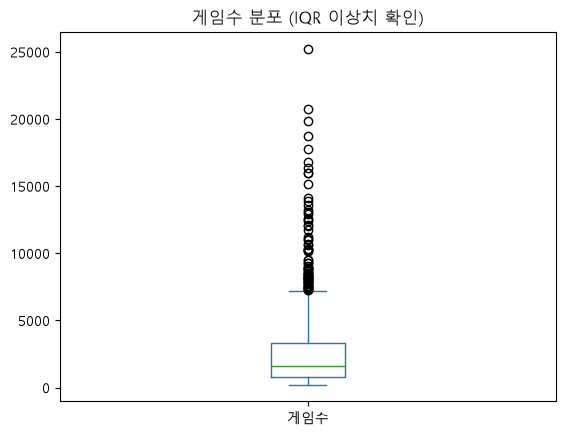

In [2]:
# 게임수(표본 수) 이상치를 IQR 기준으로 진단
q1 = tier_raw['게임수'].quantile(0.25)
q3 = tier_raw['게임수'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f'Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}')
print(f'하한={lower:.1f}, 상한={upper:.1f}')
print(f'하한 미만: {(tier_raw["게임수"] < lower).sum()}행')
print(f'상한 초과: {(tier_raw["게임수"] > upper).sum()}행')

tier_raw['게임수'].plot(kind='box', title='게임수 분포 (IQR 이상치 확인)')


Q1=-5.0, Q3=6.0, IQR=11.0
하한=-21.5, 상한=22.5
하한 미만: 22행
상한 초과: 70행


<Axes: title={'center': '순위변동 분포 (IQR 이상치 확인)'}>

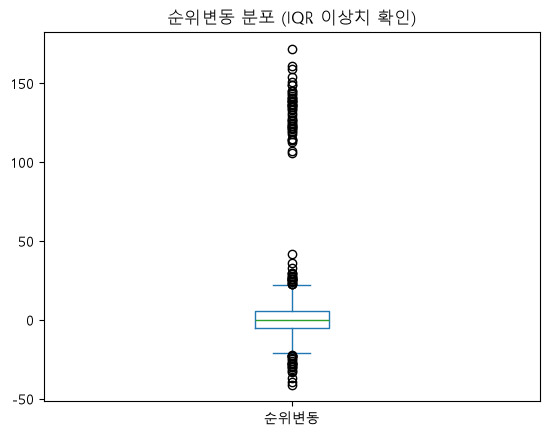

In [3]:
# 순위변동(라인 내) 컬럼의 IQR 이상치 진단
q1 = tier_raw['순위변동'].quantile(0.25)
q3 = tier_raw['순위변동'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f'Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}')
print(f'하한={lower:.1f}, 상한={upper:.1f}')
print(f'하한 미만: {(tier_raw["순위변동"] < lower).sum()}행')
print(f'상한 초과: {(tier_raw["순위변동"] > upper).sum()}행')

tier_raw['순위변동'].plot(kind='box', title='순위변동 분포 (IQR 이상치 확인)')

In [4]:
# [1단계] 완전 중복 행 제거
def drop_duplicates_step(df):
    '''1단계: 완전 중복 행 제거.'''
    return df.drop_duplicates(keep='first').reset_index(drop=True)


# [2단계] 타입/범주값 정제 — 라인·티어를 category로, bool 컬럼 정리
CATEGORY_COLS = ['라인', '티어']

def clean_categories_step(df):
    '''2단계: 라인·티어를 category dtype으로, 문자열 공백 정리.'''
    df = df.copy()
    for col in CATEGORY_COLS:
        df[col] = df[col].astype(str).str.strip().astype('category')
    df['챔피언(한국어)'] = df['챔피언(한국어)'].str.strip()
    df['챔피언(영어)'] = df['챔피언(영어)'].str.strip()
    return df


# [3단계] 날짜 파싱
def parse_date_step(df):
    '''3단계: 업데이트시각을 datetime으로 변환.'''
    df = df.copy()
    df['업데이트시각'] = pd.to_datetime(df['업데이트시각'], errors='coerce', utc=True)
    return df


# [4단계] 이상치 처리 — 게임수(표본 수) 하한 + 순위변동(라인내) 상하한을 IQR 기준으로 제거
def drop_outliers_iqr_step(df):
    '''4단계: 게임수는 하한만, 순위변동은 상하한 모두 IQR(1.5*IQR) 기준으로 제거.'''
    def bounds(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        return q1 - 1.5 * iqr, q3 + 1.5 * iqr

    games_lower, _ = bounds(df['게임수'])
    rank_lower, rank_upper = bounds(df['순위변동'])

    mask = (
        (df['게임수'] >= games_lower) &
        (df['순위변동'] >= rank_lower) &
        (df['순위변동'] <= rank_upper)
    )
    return df[mask].reset_index(drop=True)


# [5단계] 결측치 처리 — 핵심 지표 결측 행 제거 + 무의미한 컬럼 제거
REQUIRED_COLS = ['픽률(%)', '밴률(%)', '승률(%)']
USELESS_COLS = ['전체순위변동']  # 항상 0이라 정보량이 없는 컬럼

def drop_missing_core_step(df):
    '''5단계: 픽률/밴률/승률 결측 행 제거 + 값이 전부 0(무의미)인 전체순위변동 컬럼 삭제.'''
    df = df.dropna(subset=REQUIRED_COLS).reset_index(drop=True)
    return df.drop(columns=[c for c in USELESS_COLS if c in df.columns])


print('5개의 단계 함수가 정의되었습니다. 다음 셀에서 .pipe()로 묶습니다.')


5개의 단계 함수가 정의되었습니다. 다음 셀에서 .pipe()로 묶습니다.


In [5]:
# .pipe()로 5단계를 한 흐름으로 묶기
tier_clean = (
    tier_raw
    .pipe(drop_duplicates_step)
    .pipe(clean_categories_step)
    .pipe(parse_date_step)
    .pipe(drop_outliers_iqr_step)
    .pipe(drop_missing_core_step)
)

print(f'원본: {tier_raw.shape[0]}행 → 정제 후: {tier_clean.shape[0]}행')
print()
print(tier_clean.dtypes)
tier_clean.head()


원본: 1042행 → 정제 후: 950행

패치                      float64
라인                     category
챔피언(한국어)                    str
챔피언(영어)                     str
챔피언ID                     int64
라인내순위                     int64
전체순위                      int64
순위변동                      int64
티어                     category
OP픽                        bool
꿀픽                         bool
게임수                       int64
픽률(%)                   float64
밴률(%)                   float64
승률(%)                   float64
OP점수                    float64
꿀픽점수                    float64
업데이트시각      datetime64[us, UTC]
dtype: object


,패치,라인,챔피언(한국어),챔피언(영어),챔피언ID,라인내순위,전체순위,순위변동,티어,OP픽,꿀픽,게임수,픽률(%),밴률(%),승률(%),OP점수,꿀픽점수,업데이트시각
0,26.14,탑,잭스,Jax,24,1,8,0,S,False,False,2974,6.95,18.37,50.03,55.71,3.34,2026-07-23 07:26:18+00:00
1,26.14,탑,갱플랭크,Gangplank,41,2,9,1,S,False,False,2962,6.92,12.95,50.51,55.45,6.94,2026-07-23 07:26:18+00:00
2,26.14,탑,베인,Vayne,67,3,13,2,S,False,False,3011,7.03,13.27,50.58,55.21,7.58,2026-07-23 07:26:19+00:00
3,26.14,탑,요네,Yone,777,4,21,6,S,False,False,3921,9.16,7.08,50.27,54.47,6.09,2026-07-23 07:26:18+00:00
4,26.14,탑,크산테,K'Sante,897,5,23,14,S,False,False,3723,8.70,6.67,49.88,54.39,2.36,2026-07-23 07:26:18+00:00


In [6]:
# 정제된 결과 저장
tier_clean.to_csv('lolps_tierlist_clean.csv', index=False, encoding='utf-8-sig')
print('저장 완료 →', Path.cwd() / 'lolps_tierlist_clean.csv')


NameError: name 'Path' is not defined

In [7]:
# 패치노트 CSV 로드 후 tier_clean과 full outer join
patchnotes = pd.read_csv('lolps_patchnotes.csv', encoding='utf-8-sig')
print('패치노트:', patchnotes.shape)

# 조인 키 타입 맞추기 (tier_clean 패치=float64, patchnotes 패치=문자열 "26.14")
tier_clean['패치'] = tier_clean['패치'].astype(str)
patchnotes['패치'] = patchnotes['패치'].astype(str)

tier_merged = tier_clean.merge(
    patchnotes,
    left_on=['패치', '챔피언(한국어)'],
    right_on=['패치', '대상'],
    how='outer',
    indicator=True,
)

print('조인 결과:', tier_merged.shape)
print(tier_merged['_merge'].value_counts())
tier_merged.head()


패치노트: (56, 6)
조인 결과: (962, 24)
_merge
left_only     883
both           67
right_only     12
Name: count, dtype: int64


,패치,라인,챔피언(한국어),챔피언(영어),챔피언ID,라인내순위,전체순위,순위변동,티어,OP픽,...,승률(%),OP점수,꿀픽점수,업데이트시각,섹션,대상,컨텍스트,변경사항,변경수,_merge
0,26.11,탑,갈리오,Galio,3.0,53.0,216.0,0.0,C,False,...,50.29,46.51,0.27,2026-06-09 21:28:16+00:00,NaN,NaN,NaN,NaN,NaN,left_only
1,26.11,미드,갈리오,Galio,3.0,8.0,26.0,3.0,A,False,...,49.68,53.82,-0.55,2026-06-09 21:28:15+00:00,NaN,NaN,NaN,NaN,NaN,left_only
2,26.11,서폿,갈리오,Galio,3.0,39.0,210.0,6.0,C,False,...,48.08,46.95,-2.14,2026-06-09 21:28:17+00:00,NaN,NaN,NaN,NaN,NaN,left_only
3,26.11,탑,갱플랭크,Gangplank,41.0,4.0,20.0,-2.0,S,False,...,51.22,54.44,8.39,2026-06-09 21:28:16+00:00,NaN,NaN,NaN,NaN,NaN,left_only
4,26.11,탑,그라가스,Gragas,79.0,41.0,163.0,10.0,C,False,...,49.18,48.42,-1.34,2026-06-09 21:28:15+00:00,NaN,NaN,NaN,NaN,NaN,left_only


In [8]:
# 양쪽에 매칭된(both) 행만 확인 — 패치노트에 변경 이력이 있는 챔피언
tier_matched = tier_merged[tier_merged['_merge'] == 'both'].drop(columns='_merge')
print('매칭된 행:', tier_matched.shape)
tier_matched


매칭된 행: (67, 23)


,패치,라인,챔피언(한국어),챔피언(영어),챔피언ID,라인내순위,전체순위,순위변동,티어,OP픽,...,밴률(%),승률(%),OP점수,꿀픽점수,업데이트시각,섹션,대상,컨텍스트,변경사항,변경수
21,26.11,정글,다이애나,Diana,131.0,24.0,127.0,8.0,B,False,...,1.79,49.47,49.78,-0.91,2026-06-09 21:28:15+00:00,챔피언,다이애나,"다이애나는 황혼과 여명 변경에 따른 이전 조정 이후, 정글에서 다소 아쉬운 모습을 ...",몬스터 대상 피해량 : 230% ⇒ 270% | 추가 체력 : 9% ⇒ 11%,2.0
22,26.11,미드,다이애나,Diana,131.0,23.0,77.0,-2.0,B,False,...,1.79,49.81,51.21,0.25,2026-06-09 21:28:16+00:00,챔피언,다이애나,"다이애나는 황혼과 여명 변경에 따른 이전 조정 이후, 정글에서 다소 아쉬운 모습을 ...",몬스터 대상 피해량 : 230% ⇒ 270% | 추가 체력 : 9% ⇒ 11%,2.0
69,26.11,미드,브랜드,Brand,63.0,48.0,213.0,0.0,D,False,...,0.62,49.33,46.70,-0.23,2026-06-09 21:28:17+00:00,챔피언,브랜드,"브랜드는 한동안 하단 공격로에서 선을 넘나드는 모습을 보여주었으며, 이번 패치에서는...",기본 방어력 : 27 ⇒ 24,1.0
70,26.11,서폿,브랜드,Brand,63.0,47.0,248.0,-11.0,D,False,...,0.62,44.61,43.18,-4.81,2026-06-09 21:28:17+00:00,챔피언,브랜드,"브랜드는 한동안 하단 공격로에서 선을 넘나드는 모습을 보여주었으며, 이번 패치에서는...",기본 방어력 : 27 ⇒ 24,1.0
96,26.11,미드,스몰더,Smolder,901.0,54.0,257.0,-1.0,D,False,...,10.29,37.76,34.42,-6.17,2026-06-09 21:28:15+00:00,챔피언,스몰더,이 꼬마 용은 죽음불꽃 손길을 손에 넣은 후 상대를 그야말로 압도하고 있습니다. 부...,Q - 초강력 화염 숨결 추가 마법 피해량 : 용 훈련 중첩의 40% * (1 + ...,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
898,26.14,탑,제이스,Jayce,126.0,8.0,33.0,-6.0,A,False,...,30.15,47.53,53.54,-29.31,2026-07-23 07:26:18+00:00,챔피언,제이스,"제이스는 26.03 패치 조정 이후 빠르게 순위가 상승했으며, 계속해서 선두를 지키...",추가 이동 속도 : 40 ⇒ 30 | 추가 방어력 및 마법 저항력 : 5/15/25...,2.0
899,26.14,정글,제이스,Jayce,126.0,31.0,156.0,-7.0,C,False,...,30.15,46.73,49.02,-16.85,2026-07-23 07:26:18+00:00,챔피언,제이스,"제이스는 26.03 패치 조정 이후 빠르게 순위가 상승했으며, 계속해서 선두를 지키...",추가 이동 속도 : 40 ⇒ 30 | 추가 방어력 및 마법 저항력 : 5/15/25...,2.0
900,26.14,미드,제이스,Jayce,126.0,26.0,102.0,-3.0,B,False,...,30.15,49.00,50.47,-1.89,2026-07-23 07:26:18+00:00,챔피언,제이스,"제이스는 26.03 패치 조정 이후 빠르게 순위가 상승했으며, 계속해서 선두를 지키...",추가 이동 속도 : 40 ⇒ 30 | 추가 방어력 및 마법 저항력 : 5/15/25...,2.0
926,26.14,미드,코르키,Corki,42.0,53.0,247.0,-1.0,D,False,...,0.09,45.18,43.98,-6.89,2026-07-23 07:26:19+00:00,챔피언,코르키,"모두가 좋아하는, 횡설수설하는 비행사가 하단 공격로에서 이륙하는 데 말썽을 겪고 있...",공격력 증가량 : 2 ⇒ 2.5 | 기본 공격 시 남은 재충전 시간 감소량 : 2~...,2.0


순위변동 Top 20 중 패치노트 매칭: 1 / 20

      sum  count
순위방향            
상승      0     10
하락      1     10


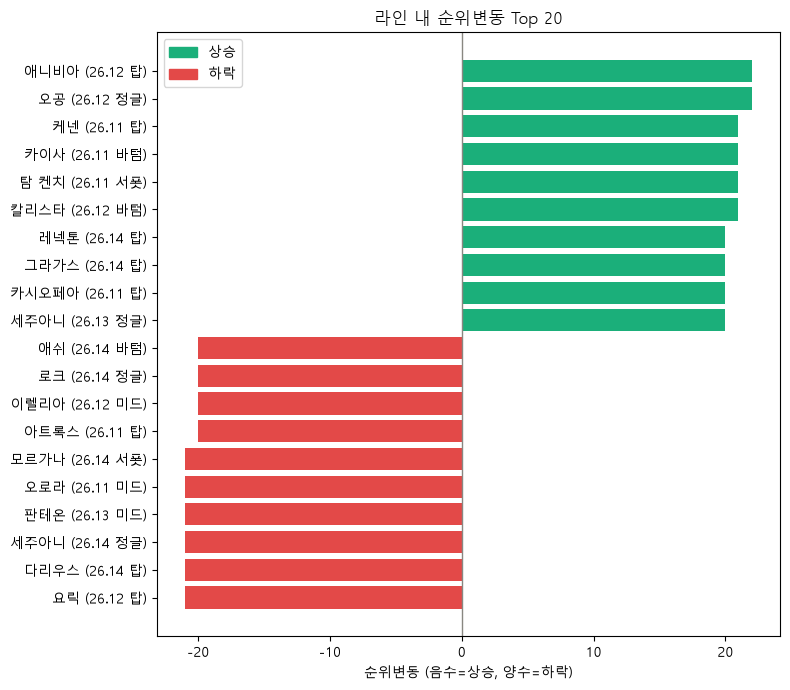

In [9]:
# 순위변동(라인 내) 폭이 큰 챔피언 Top N 추출 + 상승/하락 방향 표시
N = 20
tier_clean['순위변동_절대값'] = tier_clean['순위변동'].abs()
tier_clean['순위방향'] = tier_clean['순위변동'].apply(
    lambda x: '하락'if x < 0 else ('상승' if x > 0 else '변동없음')
)

top_variation = (
    tier_clean
    .sort_values('순위변동_절대값', ascending=False)
    .head(N)
    [['패치', '라인', '챔피언(한국어)', '라인내순위', '순위변동', '순위방향', '티어']]
)
top_variation

# 위 챔피언들이 실제로 패치노트에 변경사항이 있었는지 대조
check = top_variation.merge(
    patchnotes[['패치', '대상', '섹션', '변경사항']],
    left_on=['패치', '챔피언(한국어)'],
    right_on=['패치', '대상'],
    how='left',
)
check['패치노트_존재'] = check['대상'].notna()
check = check.drop(columns='대상')
check

# 요약: 상승/하락별로 패치노트 매칭 비율 확인
print(f"순위변동 Top {N} 중 패치노트 매칭: {check['패치노트_존재'].sum()} / {len(check)}")
print()
print(check.groupby('순위방향')['패치노트_존재'].agg(['sum', 'count']))

# 시각화: 순위변동 Top N을 상승/하락 색으로 구분한 가로 막대그래프
CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
color_map = {'상승': CATEGORICAL[2], '하락': CATEGORICAL[7]}

plot_df = top_variation.sort_values('순위변동')
colors = plot_df['순위방향'].map(color_map)

fig, ax = plt.subplots(figsize=(8, 7))
labels = plot_df['챔피언(한국어)'] + ' (' + plot_df['패치'].astype(str) + ' ' + plot_df['라인'].astype(str) + ')'
ax.barh(labels, plot_df['순위변동'], color=colors)
ax.axvline(0, color='#898781', linewidth=1)
ax.set_xlabel('순위변동 (음수=상승, 양수=하락)')
ax.set_title(f'라인 내 순위변동 Top {N}')

from matplotlib.patches import Patch
legend_elems = [Patch(color=color_map['상승'], label='상승'), Patch(color=color_map['하락'], label='하락')]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.show()

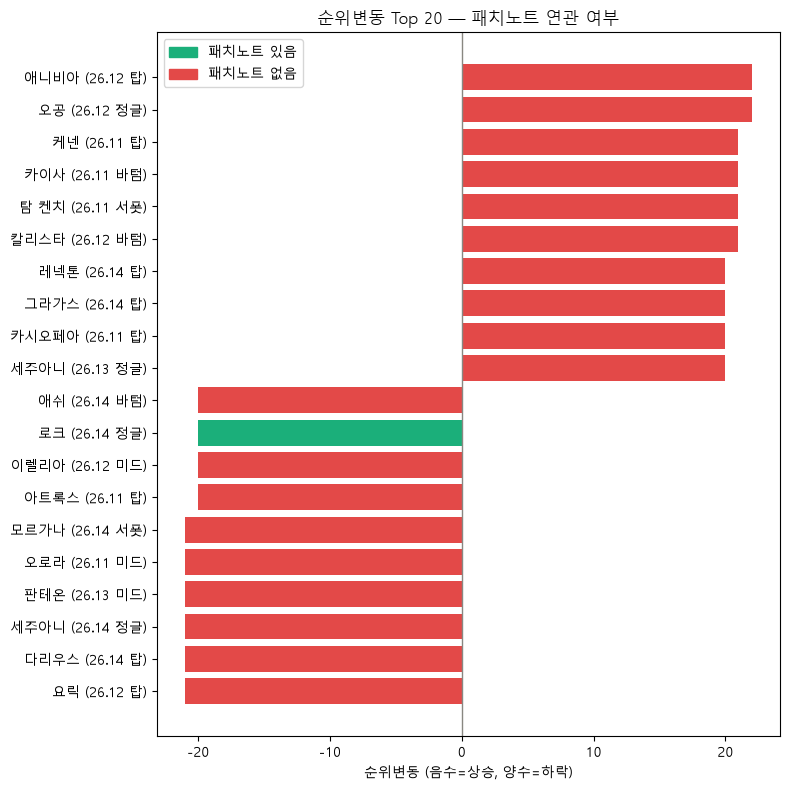

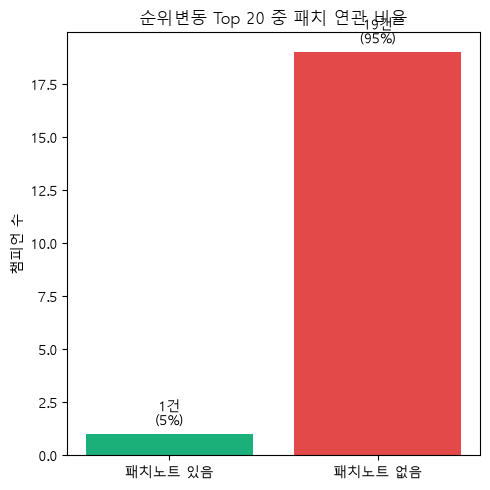

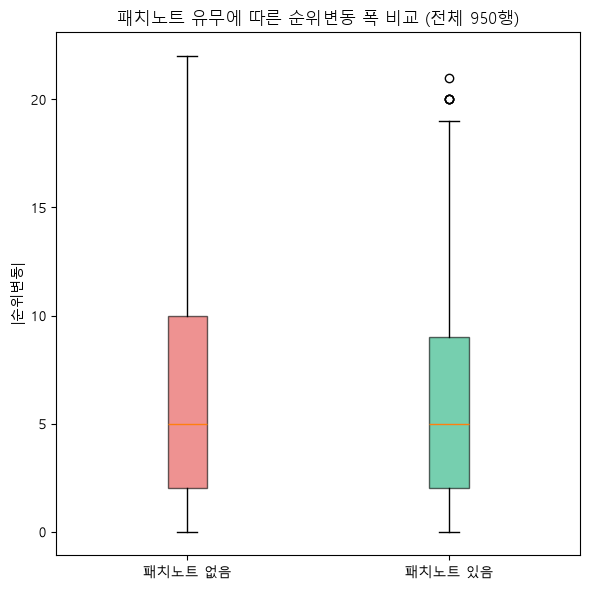

In [11]:
# 순위변동 Top 20 — 패치노트 매칭 여부를 색으로 구분한 시각화
CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
match_color_map = {True: CATEGORICAL[2], False: CATEGORICAL[7]}  # 매칭=아쿠아, 불일치=레드

plot_df = check.sort_values('순위변동')
colors = plot_df['패치노트_존재'].map(match_color_map)

fig, ax = plt.subplots(figsize=(8, 8))
labels = plot_df['챔피언(한국어)'] + ' (' + plot_df['패치'] + ' ' + plot_df['라인'].astype(str) + ')'
ax.barh(labels, plot_df['순위변동'], color=colors)
ax.axvline(0, color='#898781', linewidth=1)
ax.set_xlabel('순위변동 (음수=상승, 양수=하락)')
ax.set_title('순위변동 Top 20 — 패치노트 연관 여부')

from matplotlib.patches import Patch
legend_elems = [
    Patch(color=match_color_map[True], label='패치노트 있음'),
    Patch(color=match_color_map[False], label='패치노트 없음'),
]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.show()

# 요약 막대: 패치노트 유무별 건수 비율 (한눈에 보는 비중)
counts = check['패치노트_존재'].value_counts().reindex([True, False], fill_value=0)

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(['패치노트 있음', '패치노트 없음'], counts.values,
              color=[match_color_map[True], match_color_map[False]])
ax.set_ylabel('챔피언 수')
ax.set_title(f'순위변동 Top {len(check)} 중 패치 연관 비율')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val}건\n({val/len(check)*100:.0f}%)',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 전체 데이터(950행) 기준 — 패치노트 유무 두 그룹의 |순위변동| 분포 비교 (박스플롯)
patch_notes_champs = set(patchnotes['대상'])

group_with_note = tier_clean[tier_clean['챔피언(한국어)'].isin(patch_notes_champs)]['순위변동'].abs()
group_without_note = tier_clean[~tier_clean['챔피언(한국어)'].isin(patch_notes_champs)]['순위변동'].abs()

fig, ax = plt.subplots(figsize=(6, 6))
box = ax.boxplot(
    [group_without_note, group_with_note],
    tick_labels=['패치노트 없음', '패치노트 있음'],
    patch_artist=True,
)
for patch, color in zip(box['boxes'], [match_color_map[False], match_color_map[True]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('|순위변동|')
ax.set_title('패치노트 유무에 따른 순위변동 폭 비교 (전체 950행)')
plt.tight_layout()
plt.show()


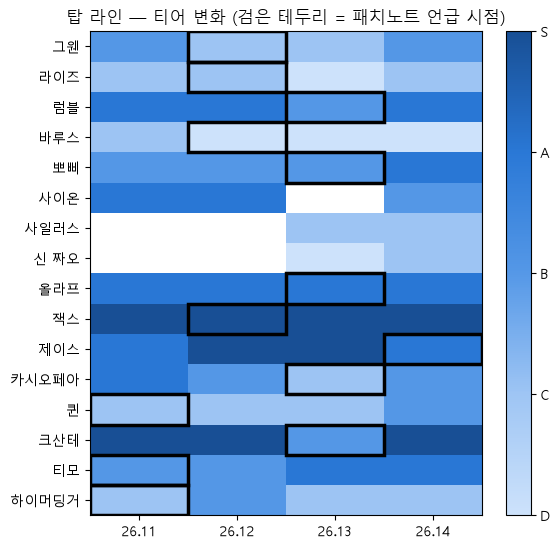

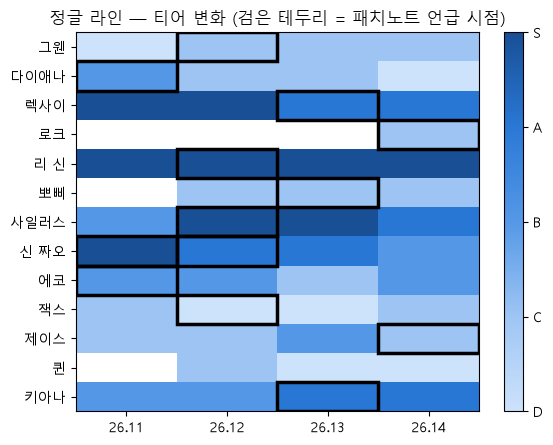

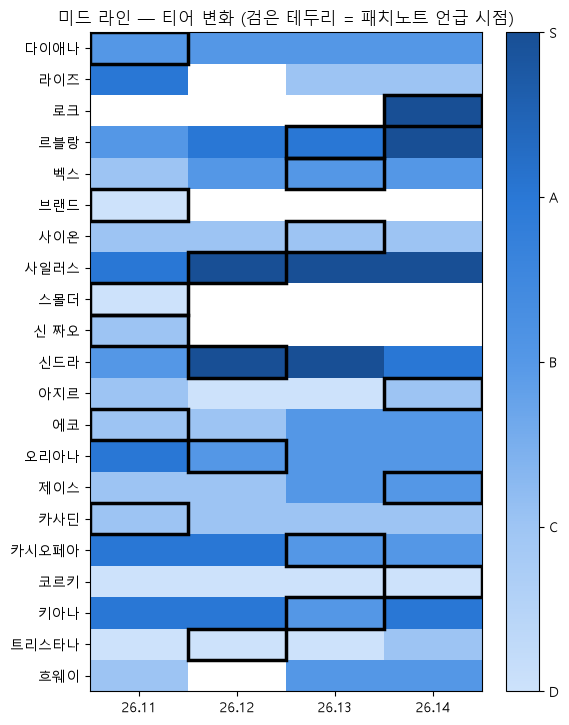

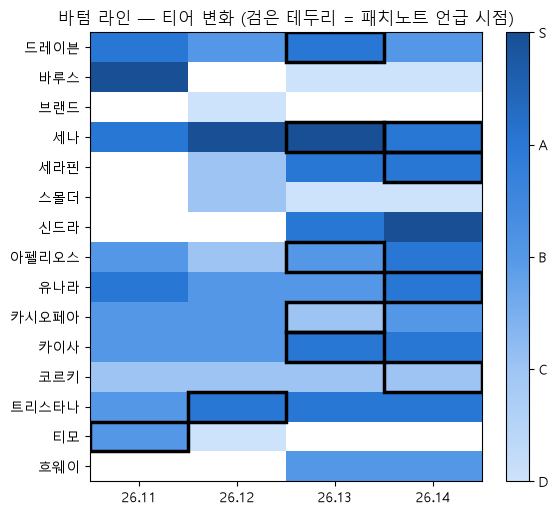

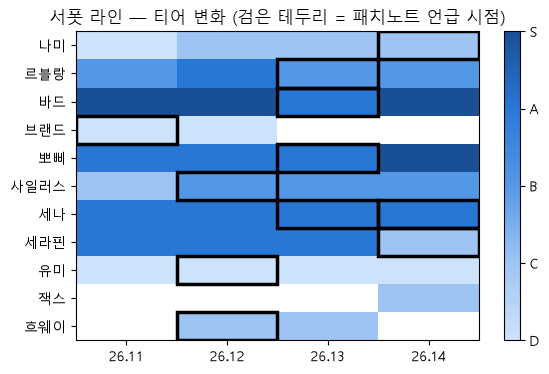

,챔피언(한국어),라인,언급패치,이전티어,언급패치티어,다음패치티어,언급패치순위변동
0,다이애나,미드,26.11,NaN,B,B,-2
1,다이애나,정글,26.11,NaN,B,C,8
2,브랜드,미드,26.11,NaN,D,NaN,0
3,브랜드,서폿,26.11,NaN,D,D,-11
4,스몰더,미드,26.11,NaN,D,NaN,-1
...,...,...,...,...,...,...,...
62,제이스,미드,26.14,B,B,NaN,-3
63,제이스,정글,26.14,B,C,NaN,-7
64,제이스,탑,26.14,S,A,NaN,-6
65,코르키,미드,26.14,D,D,NaN,-1


In [13]:
# 패치노트에 이름이 언급된 (챔피언, 패치) 조합을 표시
mentioned = tier_matched[['챔피언(한국어)', '패치']].drop_duplicates()
mentioned['언급됨'] = True

TIER_SCORE = {'S': 5, 'A': 4, 'B': 3, 'C': 2, 'D': 1}
PATCH_ORDER = ['26.11', '26.12', '26.13', '26.14']

affected_champs = tier_matched['챔피언(한국어)'].unique()

tier_history = tier_clean[tier_clean['챔피언(한국어)'].isin(affected_champs)].copy()
tier_history['티어점수'] = tier_history['티어'].astype(str).map(TIER_SCORE).astype(int)

# 챔피언-패치별로 언급 여부 표시 (라인 무관하게, 패치노트는 라인 구분 없이 챔피언 단위로 발행됨)
tier_history = tier_history.merge(mentioned, on=['챔피언(한국어)', '패치'], how='left')
tier_history['언급됨'] = tier_history['언급됨'].fillna(False)

tier_history[['패치', '라인', '챔피언(한국어)', '티어', '순위변동', '언급됨']].sort_values(
    ['챔피언(한국어)', '라인', '패치']
)

# 라인별 히트맵: x=패치, y=챔피언, 색=티어, 언급된 시점에 테두리(마커) 표시
from matplotlib.colors import LinearSegmentedColormap
SEQ_BLUE = ['#cde2fb', '#9ec5f4', '#5598e7', '#2a78d6', '#184f95']
tier_cmap = LinearSegmentedColormap.from_list('tier_seq', SEQ_BLUE)

for lane in tier_history['라인'].unique():
    sub = tier_history[tier_history['라인'] == lane]
    pivot_tier = sub.pivot_table(index='챔피언(한국어)', columns='패치', values='티어점수', aggfunc='first').reindex(columns=PATCH_ORDER)
    pivot_mention = sub.pivot_table(index='챔피언(한국어)', columns='패치', values='언급됨', aggfunc='first').reindex(columns=PATCH_ORDER)
    pivot_tier = pivot_tier.dropna(how='all')
    pivot_mention = pivot_mention.reindex(pivot_tier.index)
    if pivot_tier.empty:
        continue

    data = pivot_tier.values.astype(float)
    fig, ax = plt.subplots(figsize=(6, max(3, len(pivot_tier) * 0.35)))
    im = ax.imshow(data, aspect='auto', cmap=tier_cmap, vmin=1, vmax=5)

    # 언급된 (챔피언, 패치) 칸에 검은 테두리 마커 표시
    for i, champ in enumerate(pivot_tier.index):
        for j, patch in enumerate(pivot_tier.columns):
            if pivot_mention.iloc[i, j] == True:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=2.5))

    ax.set_xticks(range(len(pivot_tier.columns)), pivot_tier.columns)
    ax.set_yticks(range(len(pivot_tier.index)), pivot_tier.index)
    ax.set_title(f'{lane} 라인 — 티어 변화 (검은 테두리 = 패치노트 언급 시점)')
    cbar = fig.colorbar(im, ax=ax, ticks=[1, 2, 3, 4, 5])
    cbar.ax.set_yticklabels(['D', 'C', 'B', 'A', 'S'])
    plt.tight_layout()
    plt.show()

# 텍스트로도 확인: 챔피언별 "언급 패치"와 그 전후 티어/순위 비교
summary_rows = []
for champ in affected_champs:
    champ_df = tier_history[tier_history['챔피언(한국어)'] == champ].sort_values(['라인', '패치'])
    for lane in champ_df['라인'].unique():
        lane_df = champ_df[champ_df['라인'] == lane].reset_index(drop=True)
        for i, row in lane_df.iterrows():
            if row['언급됨']:
                prev_row = lane_df.iloc[i - 1] if i > 0 else None
                next_row = lane_df.iloc[i + 1] if i < len(lane_df) - 1 else None
                summary_rows.append({
                    '챔피언(한국어)': champ,
                    '라인': lane,
                    '언급패치': row['패치'],
                    '이전티어': prev_row['티어'] if prev_row is not None else None,
                    '언급패치티어': row['티어'],
                    '다음패치티어': next_row['티어'] if next_row is not None else None,
                    '언급패치순위변동': row['순위변동'],
                })

mention_summary = pd.DataFrame(summary_rows)
mention_summary

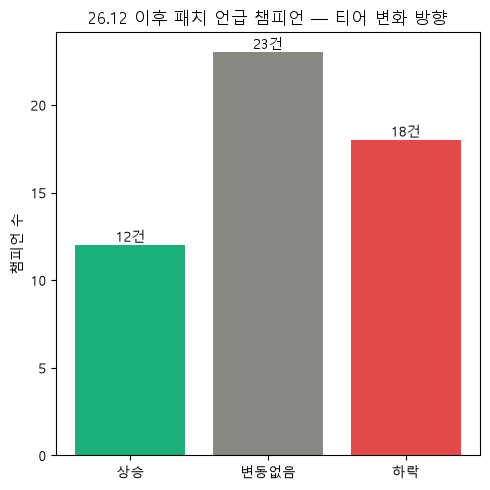

In [17]:
# 26.12 이후 언급된 건만 필터링 + 티어변화 계산
mention_valid = mention_summary[mention_summary['언급패치'] != '26.11'].copy()

TIER_SCORE = {'S': 5, 'A': 4, 'B': 3, 'C': 2, 'D': 1}
mention_valid['이전티어점수'] = mention_valid['이전티어'].map(TIER_SCORE)
mention_valid['언급티어점수'] = mention_valid['언급패치티어'].map(TIER_SCORE)
mention_valid['티어변화'] = mention_valid['언급티어점수'] - mention_valid['이전티어점수']

# 시각화: 티어변화를 상승/변동없음/하락으로 나눈 막대
tier_direction = mention_valid['티어변화'].apply(
    lambda x: '상승' if x > 0 else ('하락' if x < 0 else '변동없음')
)
counts = tier_direction.value_counts().reindex(['상승', '변동없음', '하락'], fill_value=0)

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#1baf7a', '#898781', '#e34948']
bars = ax.bar(counts.index, counts.values, color=colors)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val}건', ha='center')
ax.set_ylabel('챔피언 수')
ax.set_title('26.12 이후 패치 언급 챔피언 — 티어 변화 방향')
plt.tight_layout()
plt.show()

# 마냥 놀고 있지는 않다!